In [4]:
import pandas as pd
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
data = []

for _ in range(500):
    team_name = f"Team {chr(random.randint(65, 90))}"
    season = random.randint(2010, 2022)
    wins = random.randint(50, 110)
    losses = 162 - wins
    hits = random.randint(1200, 1600)
    doubles = random.randint(200, 350)
    triples = random.randint(10, 40)
    home_runs = random.randint(100, 250)
    strikeouts = random.randint(1000, 1500)

    # Apply adjustments to create correlations
    hits_adjusted = hits + (wins - 80) * 5
    doubles_adjusted = doubles + (wins - 80) * 2
    triples_adjusted = triples + (wins - 80)
    home_runs_adjusted = home_runs + (wins - 80) * 3
    strikeouts_adjusted = strikeouts - (wins - 80) * 10

    data.append([team_name, season, wins, losses, hits_adjusted, doubles_adjusted, triples_adjusted, home_runs_adjusted, strikeouts_adjusted])

# Define column names
columns = ["Team", "Season", "Wins", "Losses", "Hits", "Doubles", "Triples", "HomeRuns", "Strikeouts"]

# Create a Pandas DataFrame
df = pd.DataFrame(data, columns=columns)
df.head()

,Team,Season,Wins,Losses,Hits,Doubles,Triples,HomeRuns,Strikeouts
0,Team P,2022,84,78,1410,336,35,200,1444
1,Team E,2015,59,103,1413,234,-7,122,1445
2,Team H,2019,59,103,1165,261,-11,169,1484
3,Team Q,2022,82,80,1432,223,17,138,1285
4,Team Y,2021,105,57,1686,363,39,239,1029


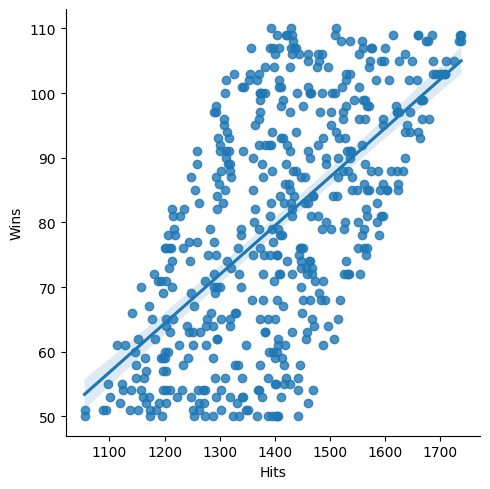

In [6]:
sns.lmplot(x="Hits", y="Wins", data=df)
plt.show()

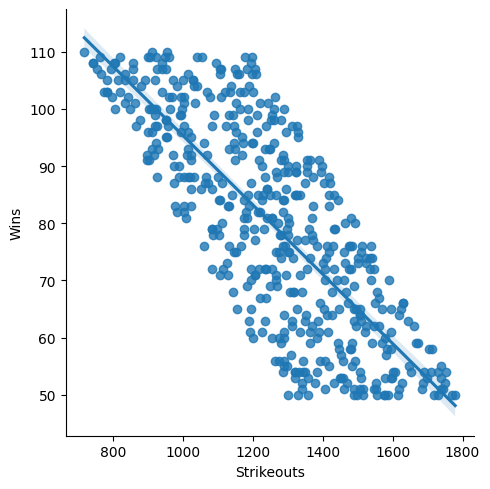

In [7]:
sns.lmplot(x="Strikeouts", y="Wins", data=df)
plt.show()

In [8]:
df2 = df.drop(columns=['Team', 'Season', 'Losses'], axis=1)

In [9]:
df2.columns

Index(['Wins', 'Hits', 'Doubles', 'Triples', 'HomeRuns', 'Strikeouts'], dtype='object')

In [10]:
X = df[['Hits', 'Doubles', 'Triples', 'HomeRuns', 'Strikeouts']]

In [11]:
y = df['Wins']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
lr.score(X_train, y_train)

0.8890224849968339

In [16]:
lr.score(X_test, y_test)

0.9002532482885197

In [17]:
y_pred = lr.predict(X_test)

In [18]:
mean_absolute_error(y_test, y_pred)

4.436907925662487

In [19]:
mean_squared_error(y_test, y_pred)

31.85169133831947

In [20]:
r2_score(y_test, y_pred)

0.9002532482885197

In [21]:
lr.coef_

array([ 0.00917358,  0.04111124,  0.44851315,  0.06319315, -0.01378023])

In [22]:
lr.intercept_

np.float64(51.33666578745955)